## Load JAX, KDExpress, and matplotlib for plotting

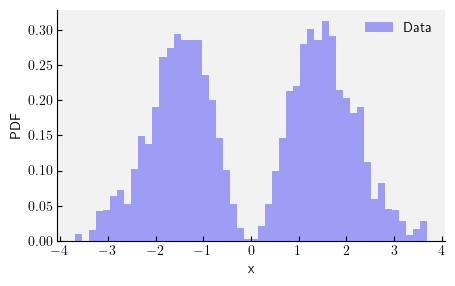

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp

import os,sys
parent_dir = os.getcwd() + '/../src/'
sys.path.append(parent_dir)
from KDExpress import fft_kde1d, binned_kde1d, build_hist_edges, scott_bw1d

import matplotlib.pyplot as plt
import matplotlib as mpl

custom_params = {
    # Spine settings - remove top/right, keep bottom/left
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    
    # Tick settings
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,        # Ensure bottom ticks are visible
    "ytick.left": True,          # Ensure left ticks are visible
    
    # Color settings
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.labelcolor": "black",
    
    # Grid settings - explicitly disable
    "axes.grid": False,
        
    # Light gray background settings
    "axes.facecolor": "0.95",    # Slightly lighter for axes background
    
    # TeX
    "text.usetex": True,
    "mathtext.fontset": "cm",
}

# First, restore default rcParams, then update
plt.rcParams.update(plt.rcParamsDefault)  # Restore defaults
plt.rcParams.update(custom_params)        # Apply your customizations


def scale_fonts_by_figsize(figsize, base_scale=1.0):
    """
    Automatically scale fonts based on figure size.
    
    Parameters
    ----------
    figsize : tuple
        Figure size in inches (width, height)
    base_scale : float
        Base scaling factor
    """
    fig_width = figsize[0]
    
    # Scale factor based on width (reference: 6.4 inches is matplotlib default)
    scale_factor = fig_width / 6.4 * base_scale
    
    font_params = {
        'font.size': 10 * scale_factor,
        'axes.titlesize': 11 * scale_factor,
        'axes.labelsize': 10 * scale_factor,
        'xtick.labelsize': 9 * scale_factor,
        'ytick.labelsize': 9 * scale_factor,
        'legend.fontsize': 8 * scale_factor,
        'figure.titlesize': 11 * scale_factor,
    }
    
    # Update only font parameters
    current_params = plt.rcParams.copy()
    current_params.update(font_params)
    plt.rcParams.update(current_params)


key = jax.random.PRNGKey(42)
data_1d = jax.random.normal(key, shape=(10_000,))
weights = data_1d**2

# Plot
plt.figure(figsize=(5,3))
plt.hist(data_1d, weights=weights, bins=50, density=True, color='blue', alpha=0.35, label='Data')
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(frameon=False)
plt.show()

 ## Generate random weighted 1-D data 

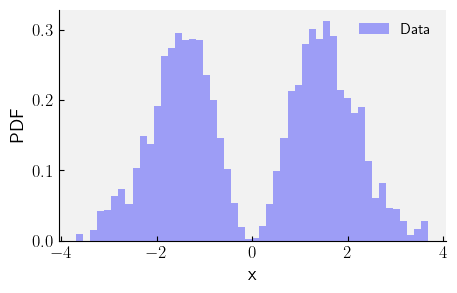

In [2]:
key = jax.random.PRNGKey(42)
data_1d = jax.random.normal(key, shape=(10_000,))
weights = data_1d**2

# Plot

scale_fonts_by_figsize(figsize=(5,3), base_scale=1.75)
plt.figure(figsize=(5,3))
plt.hist(data_1d, weights=weights, bins=50, density=True, color='blue', alpha=0.35, label='Data')
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(frameon=False)
plt.show()

## Define the points where the PDF is evaluated and compute the bin edges around them. The corresponding histogram does not appear very smooth.

Bin edges shape =  (501,)


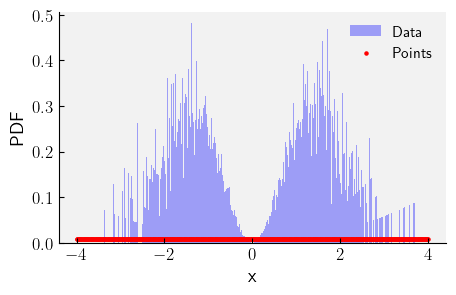

In [3]:
points = jnp.linspace(-4, 4, 500)
bin_edges = build_hist_edges(points)
print("Bin edges shape = ", bin_edges.shape)

# Plot
scale_fonts_by_figsize(figsize=(5,3), base_scale=1.75)
plt.figure(figsize=(5,3))
plt.hist(data_1d, weights=weights, bins=bin_edges, density=True, color='blue', alpha=0.35, label='Data')
plt.scatter(points, jnp.zeros_like(points)+0.008, c='red', s=5 , label='Points')
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(frameon=False)
plt.show()

## The KDE is computed by convolving the previous "wavy" histogram with a Gaussian kernel. The convolution is (efficiently) performed using an FFT.

Estimated bandwidth =  0.3372661411504573


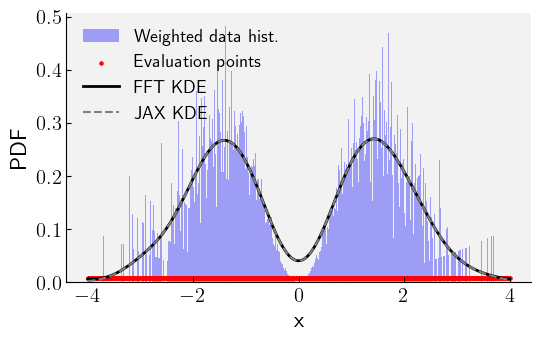

In [4]:
bw = scott_bw1d(data_1d, weights) 
print("Estimated bandwidth = ", bw)

# Compute KDE using FFT-based method (faster for large datasets)
# Note: We reuse bin_edges, though it's not strictly required. This may be useful when the grid is always the same.
pdf_est_fft = fft_kde1d(
    points, 
    data_1d, 
    weights=weights, 
    bin_edges=bin_edges, 
    bw=bw,
)

# Compute KDE using JAX's built-in gaussian_kde implementation
pdf_est_jax = jax.scipy.stats.gaussian_kde(
  data_1d, 
  weights=weights, 
  bw_method=bw/ jnp.sqrt(jnp.average((data_1d-jnp.mean(data_1d))**2, weights=weights)) # for consistency
)(points)

# Plot
plt.figure(figsize=(6, 3.5))
scale_fonts_by_figsize(figsize=(6,3.5), base_scale=1.75)
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Weighted data hist.'
)
plt.scatter(
  points, 
  jnp.zeros_like(points)+0.008,  # Small vertical offset for visibility
  c='red', 
  s=5, 
  label='Evaluation points'
)
plt.plot(
  points, 
  pdf_est_fft, 
  c='black', 
  linewidth=2,
  label='FFT KDE'
)
plt.plot(
  points, 
  pdf_est_jax, 
  c='gray', 
  linestyle='--',
  label='JAX KDE'
)

plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(frameon=False)
plt.savefig('kde_1d.pdf', bbox_inches='tight')
plt.show()

## Alternatively, we can use the binned KDE. 

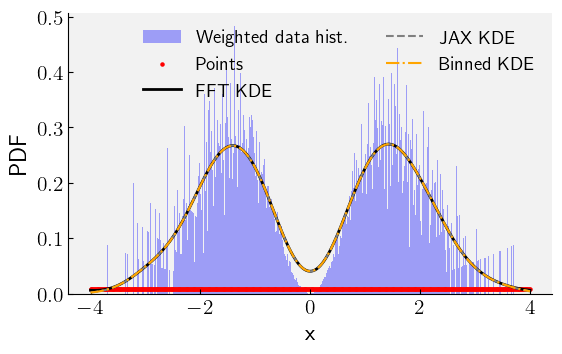

In [5]:
pdf_est_binned = binned_kde1d(points, 
  data_1d, 
  weights=weights, 
  bw = bw, 
  nbins=200 # parameter to tune
)

# Plot
scale_fonts_by_figsize(figsize=(6.25,3.65), base_scale=1.75)
plt.figure(figsize=(6.25, 3.65))
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Weighted data hist.'
)
plt.scatter(
  points, 
  jnp.zeros_like(points)+0.008,  # Small vertical offset for visibility
  c='red', 
  s=5, 
  label='Points'
)
plt.plot(
  points, 
  pdf_est_fft, 
  c='black', 
  linewidth=2,
  label='FFT KDE'
)
plt.plot(
  points, 
  pdf_est_jax, 
  c='gray', 
  linestyle='--',
  label='JAX KDE'
)
plt.plot(points, 
  pdf_est_binned, 
  c='orange', 
  ls='-.', 
  label='Binned KDE'
)

plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(ncols=2, frameon=False)  
plt.savefig('kde_1d_with_binned.pdf', bbox_inches='tight')
plt.show()

## The binned KDE can also truncate points outside cut_sigma_points standard deviations from the data support. This speeds up KDE evaluation when the evaluation points range is much larger than the dataset's one. In such cases, the FFT-based KDE remains efficient due to its inherent histogram-based computation.

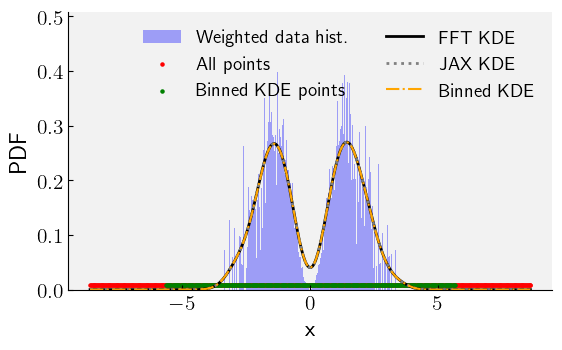

In [6]:
# Create evaluation points extending 5 standard deviations beyond data range
min_data = jnp.min(data_1d)
max_data = jnp.max(data_1d)
std_data = jnp.std(data_1d)

large_support_points = jnp.linspace(
  min_data - 5*std_data, 
  max_data + 5*std_data, 
  500
)

# Create effective points for binned KDE evaluation (2 sigma range) only for visualization.
# This is the same "effective grid" that is created within binned_kde1d.
# Outisde this "effective grid" binned_kde1d is zero.
# These are the actual points where binned KDE is computed before interpolation
cut_sigma_data = 2
eff_points = jnp.linspace(
  min_data - cut_sigma_data*std_data,
  max_data + cut_sigma_data*std_data,
  len(large_support_points)//2  
)

# Compute KDE using different methods:
# 1. Binned KDE 
pdf_est_binned_2 = binned_kde1d(
  large_support_points, 
  data_1d, 
  weights=weights, 
  bw=bw,
  nbins=200,  
  cut_sigma_data=2  
)

# 2. FFT-based KDE
pdf_est_fft_2 = fft_kde1d(
  large_support_points, 
  data_1d, 
  weights=weights, 
  bw=bw
)

# 3. JAX's built-in Gaussian KDE
pdf_est_jax_2 = jax.scipy.stats.gaussian_kde(
    data_1d, 
    weights=weights, 
    bw_method=bw/jnp.sqrt(jnp.average((data_1d-jnp.mean(data_1d))**2, weights=weights)) # for consistency
)(large_support_points)

# Plot
scale_fonts_by_figsize(figsize=(6.25,3.6), base_scale=1.75)
plt.figure(figsize=(6.25, 3.6))
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Weighted data hist.'
)
plt.scatter(
  large_support_points, 
  jnp.zeros_like(large_support_points) + 0.008,  # Small offset for visibility
  c='red', 
  s=5, 
  label='All points'
)
plt.scatter(
  eff_points, 
  jnp.zeros_like(eff_points) + 0.008,
  c='green', 
  s=5, 
  label='Binned KDE points'
)
plt.plot(
  large_support_points, 
  pdf_est_fft_2, 
  c='black', 
  linewidth=2,
  label='FFT KDE'
)
plt.plot(
  large_support_points, 
  pdf_est_jax_2, 
  c='gray', 
  linestyle=':', 
  linewidth=2,
  label='JAX KDE'
)
plt.plot(
  large_support_points, 
  pdf_est_binned_2, 
  c='orange', 
  linestyle='-.',
  label='Binned KDE'
)
plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(ncols=2, frameon=False)  
plt.savefig('kde_1d_large_range.pdf', bbox_inches='tight')
plt.show()

## One can use also the Epanechnikov kernel

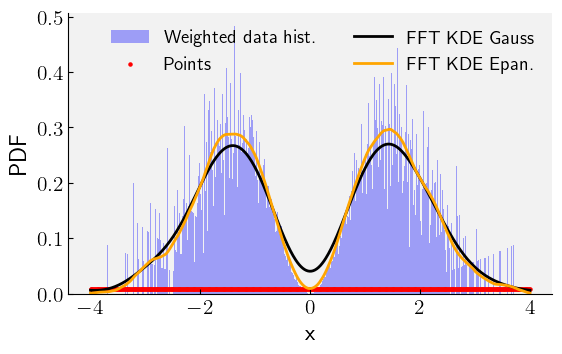

In [11]:
pdf_fft_gauss = fft_kde1d(
    points, 
    data_1d, 
    weights=weights, 
    bin_edges=bin_edges, 
    bw=bw,
)

pdf_fft_epan = fft_kde1d(
    points, 
    data_1d, 
    weights=weights, 
    bin_edges=bin_edges, 
    bw=bw,
    kernel='epan'
)

# Plot
scale_fonts_by_figsize(figsize=(6.25,3.65), base_scale=1.75)
plt.figure(figsize=(6.25, 3.65))
plt.hist(
  data_1d, 
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  color='blue', 
  alpha=0.35, 
  label='Weighted data hist.'
)
plt.scatter(
  points, 
  jnp.zeros_like(points)+0.008,  # Small vertical offset for visibility
  c='red', 
  s=5, 
  label='Points'
)
plt.plot(
  points, 
  pdf_fft_gauss, 
  c='black', 
  linewidth=2,
  label='FFT KDE Gauss'
)
plt.plot(
  points, 
  pdf_fft_epan, 
  c='orange', 
  linestyle='-', lw='2',
  label='FFT KDE Epan.'
)

plt.ylabel("PDF")
plt.xlabel("x")
plt.legend(ncols=2, frameon=False)  
plt.savefig('kde_1d_fft_epan_vs_gauss.pdf', bbox_inches='tight')
plt.show()

In [22]:
%timeit fft_kde1d(points, data_1d, weights=weights).block_until_ready()

233 μs ± 22.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [23]:
%timeit fft_kde1d(points, data_1d, weights=weights, kernel='epan').block_until_ready()

233 μs ± 32.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [24]:
%timeit binned_kde1d(points, data_1d, weights=weights).block_until_ready()

970 μs ± 347 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [25]:
%timeit binned_kde1d(points, data_1d, weights=weights, kernel='epan').block_until_ready()

485 μs ± 64.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [26]:
def jax_kde_1d(points, data, weights, bw) :
    return jax.scipy.stats.gaussian_kde(
              data, 
              weights=weights, 
              bw_method=bw/ jnp.sqrt(jnp.average((data_1d-jnp.mean(data_1d))**2, weights=weights)) # for consistency
            )(points)

jax_kde_1d(large_support_points, data_1d, weights=weights, bw=bw)
%timeit jax_kde_1d(large_support_points, data_1d, weights=weights, bw=bw).block_until_ready()

24.8 ms ± 3.08 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
